In [1]:
import os
import json
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import utils

In [2]:
PHENOTYPE_PATH = os.path.join(utils.DATASET_PATH, 'phenotype', 'phenotype_preprocessed.tsv')
HOLDOUTS05_PATH = os.path.join(utils.HOLDOUTS_PATH, '05_holdouts')
SUBJECTS_PATH = os.path.join(utils.DATASET_PATH, 'sub-*')
CONTRAST_NAME = 'incongruent_vs_congruent'
ALT_TEST = 'Incongruent > Congruent'
ALPHA1 = 0.05
ALPHA2 = 0.01
HEIGHT_CONTROL1 = 'fpr'
HEIGHT_CONTROL2 = 'fdr'
ATLAS1 = 'schaefer'
N_ROIS1 = 1000
YN1 = 17
FEATURE_TABLE_NAME = 'ML_Dataset'

In [3]:
holdouts_info = utils.load_file(HOLDOUTS05_PATH, 'holdouts05_split_ids.json')
print(holdouts_info)

{'holdout-01': {'slglm': [23735, 23985, 23664, 24212, 23996, 24270, 24240, 23865, 24148, 23501, 22860, 23923, 24142, 22623, 22268, 23480, 22494, 23892, 20131, 24182, 22829, 21100, 22482, 24106, 23878, 24004, 22600, 24127, 23524, 24091, 23303, 23584, 23545, 24118, 22871, 22831, 24022, 22172, 22365, 22687, 24275, 23567, 22477, 22956, 23910, 23601, 24236, 23382, 22862, 23010, 23986, 23072, 23822, 23314, 23631, 23946, 24050, 23294, 23534, 22906], 'ml': [22734, 22818, 22847, 22873, 23014, 23028, 23044, 23123, 23257, 23261, 23317, 23342, 23353, 23362, 23376, 23381, 23386, 23392, 23407, 23432, 23442, 23483, 23485, 23494, 23532, 23559, 23568, 23572, 23622, 23629, 23690, 23749, 23762, 23779, 23842, 23855, 23871, 23883, 23925, 23971, 23972, 23979, 23987, 23991, 24015, 24017, 24021, 24029, 24033, 24038, 24039, 24040, 24046, 24067, 24073, 24089, 24115, 24139, 24145, 24146, 24151, 24197, 24198, 24217, 24260, 24276, 24300, 24353, 20209, 20725, 21214, 21508, 22281, 22286, 22295, 22346, 22353, 22354, 

In [4]:
phenotype = pd.read_csv(PHENOTYPE_PATH, delimiter='\t')
phenotype.sample(5)

,participant_id,sex,age_baseline,KSADS_MAIN_DIAGNOSIS,WASI_FULL_2_IQ,INCOME,RACE_WHITE,RACE_BLACK,RACE_ASIAN,RACE_MULTIPLE,ETHNICITY,COHORT,SCANNER,SCARED_BASELINE_YOUTH_RATING,SCARED_BASELINE_PARENT_RATING,CGAS_BASELINE_SCORE,PARS_BASELINE_CLINICIAN_RATING,IQ_IS_MISSING,INCOME_IS_MISSING
87,sub-023749,-1.0,13.0,ANX,118.0,9.0,1.0,-1.0,-1.0,-1.0,-1.0,-1,-1,47.0,34.9,60.0,13.0,-1,-1
17,sub-022381,1.0,15.0,HV,94.0,8.0,-1.0,-1.0,-1.0,1.0,1.0,1,1,4.0,3.0,NaN,NaN,-1,-1
96,sub-023883,1.0,11.0,ANX,127.0,9.0,1.0,-1.0,-1.0,-1.0,-1.0,-1,1,35.0,29.0,60.0,15.0,-1,-1
82,sub-023629,-1.0,9.0,ANX,108.0,3.0,-1.0,-1.0,-1.0,1.0,1.0,-1,-1,26.0,29.0,41.0,NaN,-1,-1
1,sub-020209,1.0,16.0,HV,118.0,8.0,1.0,-1.0,-1.0,-1.0,-1.0,1,1,23.0,17.0,NaN,NaN,-1,-1


In [5]:
phenotype.columns

Index(['participant_id', 'sex', 'age_baseline', 'KSADS_MAIN_DIAGNOSIS',
       'WASI_FULL_2_IQ', 'INCOME', 'RACE_WHITE', 'RACE_BLACK', 'RACE_ASIAN',
       'RACE_MULTIPLE', 'ETHNICITY', 'COHORT', 'SCANNER',
       'SCARED_BASELINE_YOUTH_RATING', 'SCARED_BASELINE_PARENT_RATING',
       'CGAS_BASELINE_SCORE', 'PARS_BASELINE_CLINICIAN_RATING',
       'IQ_IS_MISSING', 'INCOME_IS_MISSING'],
      dtype='object')

In [6]:
key, val = list(holdouts_info.items())[0]
print(key)
print(val)

holdout-01
{'slglm': [23735, 23985, 23664, 24212, 23996, 24270, 24240, 23865, 24148, 23501, 22860, 23923, 24142, 22623, 22268, 23480, 22494, 23892, 20131, 24182, 22829, 21100, 22482, 24106, 23878, 24004, 22600, 24127, 23524, 24091, 23303, 23584, 23545, 24118, 22871, 22831, 24022, 22172, 22365, 22687, 24275, 23567, 22477, 22956, 23910, 23601, 24236, 23382, 22862, 23010, 23986, 23072, 23822, 23314, 23631, 23946, 24050, 23294, 23534, 22906], 'ml': [22734, 22818, 22847, 22873, 23014, 23028, 23044, 23123, 23257, 23261, 23317, 23342, 23353, 23362, 23376, 23381, 23386, 23392, 23407, 23432, 23442, 23483, 23485, 23494, 23532, 23559, 23568, 23572, 23622, 23629, 23690, 23749, 23762, 23779, 23842, 23855, 23871, 23883, 23925, 23971, 23972, 23979, 23987, 23991, 24015, 24017, 24021, 24029, 24033, 24038, 24039, 24040, 24046, 24067, 24073, 24089, 24115, 24139, 24145, 24146, 24151, 24197, 24198, 24217, 24260, 24276, 24300, 24353, 20209, 20725, 21214, 21508, 22281, 22286, 22295, 22346, 22353, 22354, 2236

In [7]:
for key, val in list(holdouts_info.items())[:1]:
    print(key,val)

holdout-01 {'slglm': [23735, 23985, 23664, 24212, 23996, 24270, 24240, 23865, 24148, 23501, 22860, 23923, 24142, 22623, 22268, 23480, 22494, 23892, 20131, 24182, 22829, 21100, 22482, 24106, 23878, 24004, 22600, 24127, 23524, 24091, 23303, 23584, 23545, 24118, 22871, 22831, 24022, 22172, 22365, 22687, 24275, 23567, 22477, 22956, 23910, 23601, 24236, 23382, 22862, 23010, 23986, 23072, 23822, 23314, 23631, 23946, 24050, 23294, 23534, 22906], 'ml': [22734, 22818, 22847, 22873, 23014, 23028, 23044, 23123, 23257, 23261, 23317, 23342, 23353, 23362, 23376, 23381, 23386, 23392, 23407, 23432, 23442, 23483, 23485, 23494, 23532, 23559, 23568, 23572, 23622, 23629, 23690, 23749, 23762, 23779, 23842, 23855, 23871, 23883, 23925, 23971, 23972, 23979, 23987, 23991, 24015, 24017, 24021, 24029, 24033, 24038, 24039, 24040, 24046, 24067, 24073, 24089, 24115, 24139, 24145, 24146, 24151, 24197, 24198, 24217, 24260, 24276, 24300, 24353, 20209, 20725, 21214, 21508, 22281, 22286, 22295, 22346, 22353, 22354, 2236

**kernel pca, manifold, svm (try rbf and other solvers; in rbf we can see what functions/dimensions are being used)**

Holdout ID: 01
Computed group mean task-fmri
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps


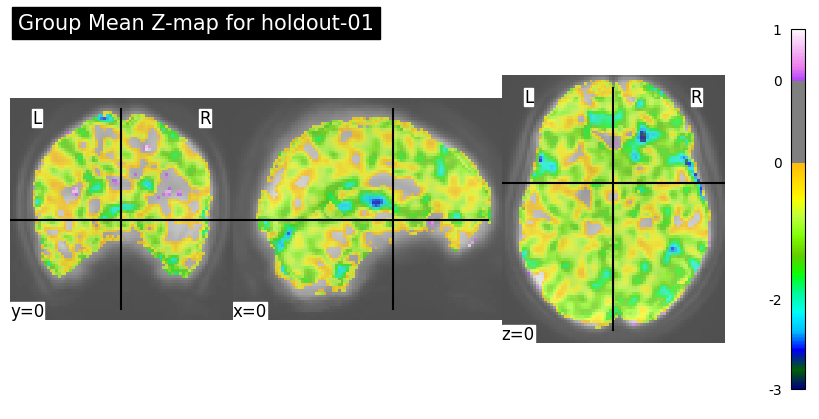

Threshold: 1.960
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates


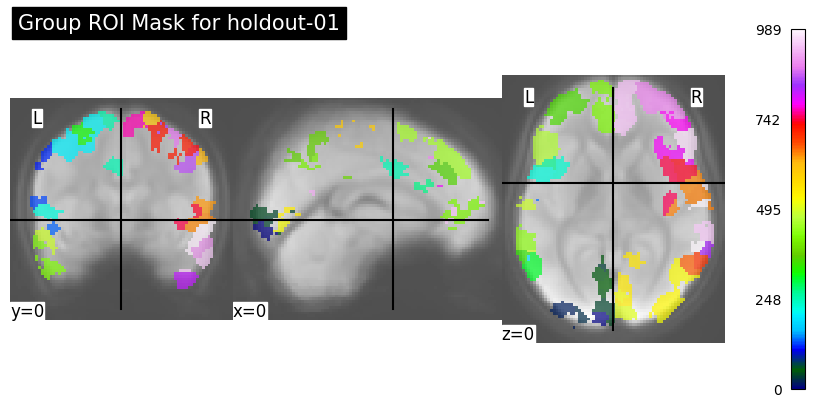

425 ROIs found
Subjects completed:


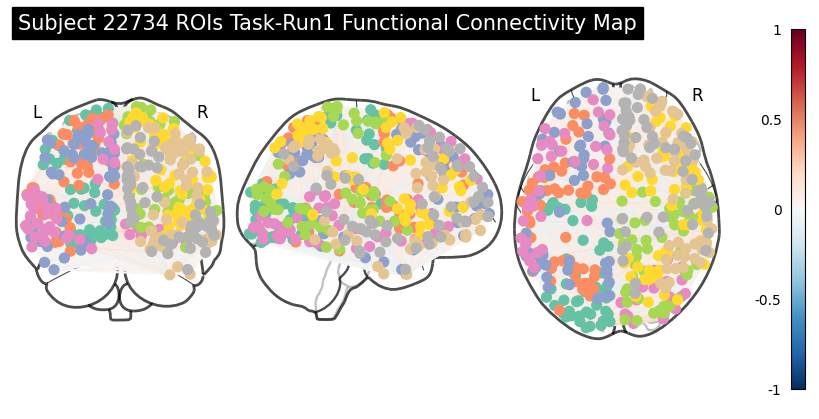

KeyboardInterrupt: 

In [ ]:
for key, val in list(holdouts_info.items())[:1]:
    print(f"Holdout ID: {key.split('-')[1]}")
    
    # Path of the current holdout's subdirectory
    holdout_i_path = os.path.join(HOLDOUTS05_PATH, key)
    
    # Get task-based group ROIs
    group_mean_tfmri, group_mean_task_zmap = utils.get_group_mean_maps(
        sub_list=val['slglm'], 
        phenotype_table=phenotype, 
        fl_contrast_name=CONTRAST_NAME, 
        fl_contrast_map_verbose=2,
        sl_verbose=0,
        show_sl_design_matrix=False,
        save_group_mean_tfmri=True, 
        save_group_mean_tfmri_path=holdout_i_path, 
        save_fl_contrasts=True, 
        save_fl_contrasts_path=holdout_i_path, 
        save_sl_design_matrix=True, 
        save_sl_design_matrix_path=holdout_i_path, 
        save_mean_task_zmap=True, 
        save_mean_task_zmap_path=holdout_i_path
    )

    utils.plot_map(
        'roi',
        group_mean_task_zmap,
        f"Group Mean Z-map for {key}",
        group_mean_tfmri
    )

    group_ROIs_mask, group_ROIs_table, alpha_sub_directory = utils.get_group_task_ROIs(
        group_mean_zmap=group_mean_task_zmap, 
        group_mean_fmri=group_mean_tfmri, 
        alpha=ALPHA1, height_control=HEIGHT_CONTROL1, two_sided=True, 
        atlas_name=ATLAS1, n_rois=N_ROIS1, yeo_networks=YN1, 
        save_thresholded_zmap=True, 
        save_thresholded_zmap_path=holdout_i_path, 
        save_ROIs_mask=True, 
        save_ROIs_mask_path=holdout_i_path
    )

    utils.plot_map(
        'roi',
        group_ROIs_mask,
        f"Group ROI Mask for {key}",
        group_mean_tfmri
    )

    print(f"{len(group_ROIs_table)} ROIs found")
    # print(f"{group_ROIs_table['label'].values.tolist()}\n")

    holdout_i_alpha_j_path = os.path.join(holdout_i_path, alpha_sub_directory)
    
    # Get ML Dataset
    ml_dataset = utils.create_ml_dataset(
        sub_list=val['ml'], 
        phenotype_table=phenotype, 
        group_ROIs_mask=group_ROIs_mask, 
        group_ROIs_table=group_ROIs_table, 
        fl_contrast_name=CONTRAST_NAME, 
        fl_alt_test=ALT_TEST, 
        show_ROIs_connectomes=True,
        save_zmaps=True, save_zmaps_path=holdout_i_path, 
        save_ROIs_zmaps=True, save_ROIs_zmaps_path=holdout_i_alpha_j_path,
        save_ROIs_rest_FC_matrices=True, save_ROIs_rest_FC_matrices_path=holdout_i_alpha_j_path, 
        save_table=True, save_name=f"{FEATURE_TABLE_NAME}_{key}.csv", save_path=holdout_i_alpha_j_path
    )
    print(f"Shape of ML Dataset: {ml_dataset.shape}")
    display(ml_dataset.sample(5))
    print()

Holdout ID: 01
Computed group mean task-fmri
Loading ..\dataset_holdouts\05_holdouts\holdout-01\fl_incongruent_vs_congruent-contrast_maps_60subs.nii.gz
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps


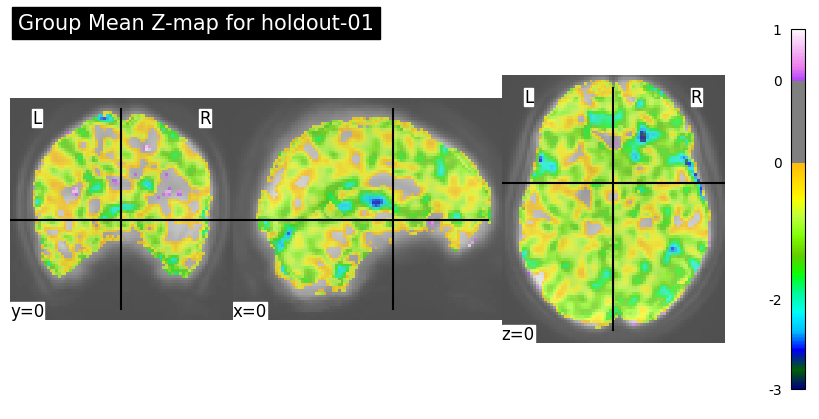

Threshold: 2.576
Thresholded the group-task-mean Z-map
Loading ..\resampled_atlases\resampled_schaefer_1000_17.nii
Loading ..\resampled_atlases\resampled_schaefer_1000_17_label_coords.csv
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates


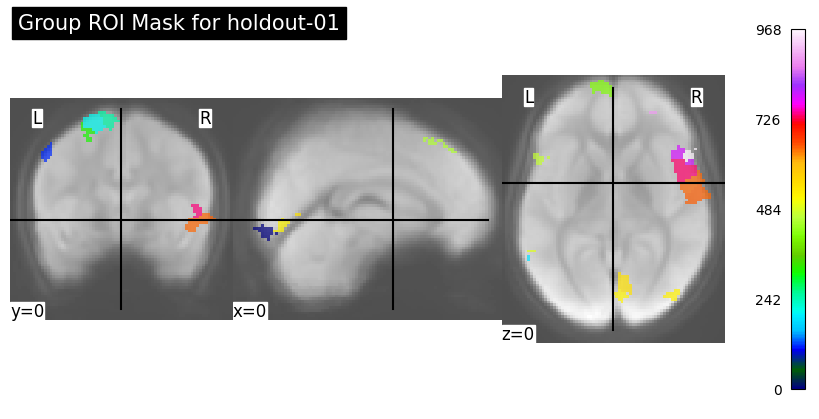

95 ROIs found
Loading ..\dataset_holdouts\05_holdouts\holdout-01\fl_incongruent_vs_congruent-contrast_zmaps_89subs.nii.gz
Loading ..\dataset_holdouts\05_holdouts\holdout-01\uncorrected_alpha-0.01_two-sided\fl_incongruent_vs_congruent-contrast_zmaps_95ROIs_89subs.nii.gz
Loading ..\dataset_holdouts\05_holdouts\holdout-01\uncorrected_alpha-0.01_two-sided\rs-FunctionalConnectivity-matrices_95ROIs_89subs.npy
Subjects completed:
22734, 22818, 

KeyboardInterrupt: 

In [6]:
for key, val in list(holdouts_info.items())[:2]:
    print(f"Holdout ID: {key.split('-')[1]}")
    
    # Path of the current holdout's subdirectory
    holdout_i_path = os.path.join(HOLDOUTS05_PATH, key)
    
    # Get task-based group ROIs
    group_mean_tfmri, group_mean_task_zmap = utils.get_group_mean_maps(
        sub_list=val['slglm'], 
        phenotype_table=phenotype, 
        fl_contrast_name=CONTRAST_NAME, 
        fl_contrast_map_verbose=2,
        sl_verbose=0,
        show_sl_design_matrix=False,
        save_group_mean_tfmri=True, 
        save_group_mean_tfmri_path=holdout_i_path, 
        save_fl_contrasts=True, 
        save_fl_contrasts_path=holdout_i_path, 
        save_sl_design_matrix=True, 
        save_sl_design_matrix_path=holdout_i_path, 
        save_mean_task_zmap=True, 
        save_mean_task_zmap_path=holdout_i_path
    )

    utils.plot_map(
        'roi',
        group_mean_task_zmap,
        f"Group Mean Z-map for {key}",
        group_mean_tfmri
    )

    group_ROIs_mask, group_ROIs_table, sub_directory = utils.get_group_task_ROIs(
        group_mean_zmap=group_mean_task_zmap, 
        group_mean_fmri=group_mean_tfmri, 
        alpha=0.01, height_control=utils.HEIGHT_CONTROL, two_sided=True, 
        atlas_name='schaefer', n_rois=1000, yeo_networks=17, 
        save_thresholded_zmap=True, 
        save_thresholded_zmap_path=holdout_i_path, 
        save_ROIs_mask=True, 
        save_ROIs_mask_path=holdout_i_path
    )

    utils.plot_map(
        'roi',
        group_ROIs_mask,
        f"Group ROI Mask for {key}",
        group_mean_tfmri
    )

    print(f"{len(group_ROIs_table)} ROIs found")
    # print(f"{group_ROIs_table['label'].values.tolist()}\n")

    # Get ML Dataset
    ml_dataset = utils.create_ml_dataset(
        sub_list=val['ml'], 
        phenotype_table=phenotype, 
        group_ROIs_mask=group_ROIs_mask, 
        group_ROIs_table=group_ROIs_table, 
        fl_contrast_name=CONTRAST_NAME, 
        fl_alt_test=ALT_TEST, 
        save_zmaps=True, save_zmaps_path=holdout_i_path, 
        save_ROIs_zmaps=True, save_ROIs_zmaps_path=os.path.join(holdout_i_path, sub_directory),
        save_ROIs_rest_FC_matrices=True, save_ROIs_rest_FC_matrices_path=os.path.join(holdout_i_path, sub_directory), 
        save_table=True, save_name=f"ml_dataset_{key}.csv", 
        save_path=os.path.join(holdout_i_path, sub_directory)
    )
    print(f"Shape of ML Dataset: {ml_dataset.shape}")
    display(ml_dataset.sample(5))
    print()

Holdout ID: 02
Computed group mean task-fmri
Loading ..\dataset_holdouts\05_holdouts\holdout-02\fl_incongruent_vs_congruent-contrast_maps_60subs.nii.gz
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps


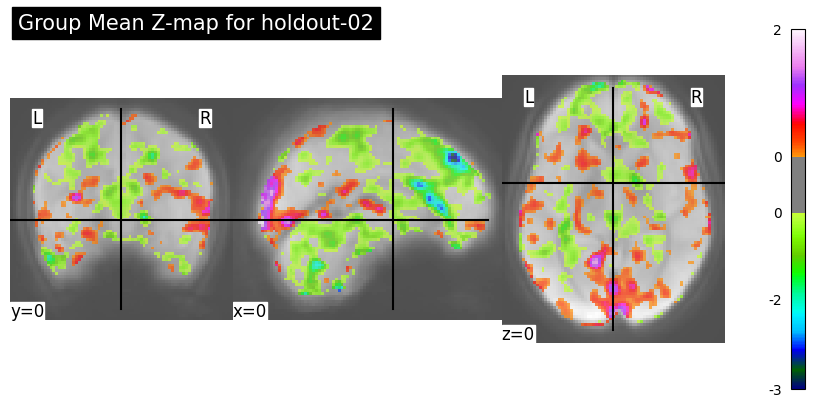

Threshold: 2.576
Thresholded the group-task-mean Z-map
Loading ..\resampled_atlases\resampled_schaefer_1000_17.nii
Loading ..\resampled_atlases\resampled_schaefer_1000_17_label_coords.csv
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates


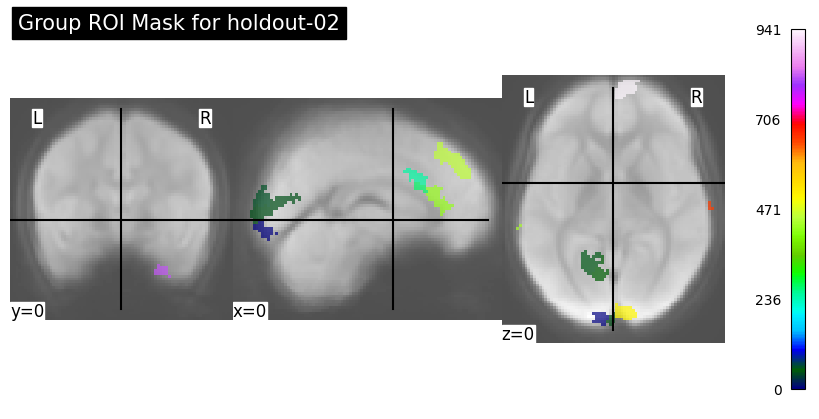

32 ROIs found
Loading ..\dataset_holdouts\05_holdouts\holdout-02\fl_incongruent_vs_congruent-contrast_zmaps_89subs.nii.gz
Loading ..\dataset_holdouts\05_holdouts\holdout-02\uncorrected_alpha-0.01_two-sided\fl_incongruent_vs_congruent-contrast_zmaps_32ROIs_89subs.nii.gz
Loading ..\dataset_holdouts\05_holdouts\holdout-02\uncorrected_alpha-0.01_two-sided\rs-FunctionalConnectivity-matrices_32ROIs_89subs.npy
Subjects completed:


KeyboardInterrupt: 

In [6]:
for key, val in list(holdouts_info.items())[1:2]:
    print(f"Holdout ID: {key.split('-')[1]}")
    
    # Path of the current holdout's subdirectory
    holdout_i_path = os.path.join(HOLDOUTS05_PATH, key)
    
    # Get task-based group ROIs
    group_mean_tfmri, group_mean_task_zmap = utils.get_group_mean_maps(
        sub_list=val['slglm'], 
        phenotype_table=phenotype, 
        fl_contrast_name=CONTRAST_NAME, 
        fl_contrast_map_verbose=2,
        sl_verbose=0,
        show_sl_design_matrix=False,
        save_group_mean_tfmri=True, 
        save_group_mean_tfmri_path=holdout_i_path, 
        save_fl_contrasts=True, 
        save_fl_contrasts_path=holdout_i_path, 
        save_sl_design_matrix=True, 
        save_sl_design_matrix_path=holdout_i_path, 
        save_mean_task_zmap=True, 
        save_mean_task_zmap_path=holdout_i_path
    )

    utils.plot_map(
        'roi',
        group_mean_task_zmap,
        f"Group Mean Z-map for {key}",
        group_mean_tfmri
    )

    group_ROIs_mask, group_ROIs_table, sub_directory = utils.get_group_task_ROIs(
        group_mean_zmap=group_mean_task_zmap, 
        group_mean_fmri=group_mean_tfmri, 
        alpha=0.01, height_control=utils.HEIGHT_CONTROL, two_sided=True, 
        atlas_name='schaefer', n_rois=1000, yeo_networks=17, 
        save_thresholded_zmap=True, 
        save_thresholded_zmap_path=holdout_i_path, 
        save_ROIs_mask=True, 
        save_ROIs_mask_path=holdout_i_path
    )

    utils.plot_map(
        'roi',
        group_ROIs_mask,
        f"Group ROI Mask for {key}",
        group_mean_tfmri
    )

    print(f"{len(group_ROIs_table)} ROIs found")
    # print(f"{group_ROIs_table['label'].values.tolist()}\n")

    # Get ML Dataset
    ml_dataset = utils.create_ml_dataset(
        sub_list=val['ml'], 
        phenotype_table=phenotype, 
        group_ROIs_mask=group_ROIs_mask, 
        group_ROIs_table=group_ROIs_table, 
        fl_contrast_name=CONTRAST_NAME, 
        fl_alt_test=ALT_TEST, 
        save_zmaps=True, save_zmaps_path=holdout_i_path, 
        save_ROIs_zmaps=True, save_ROIs_zmaps_path=os.path.join(holdout_i_path, sub_directory),
        save_ROIs_rest_FC_matrices=True, save_ROIs_rest_FC_matrices_path=os.path.join(holdout_i_path, sub_directory), 
        save_table=True, save_name=f"ml_dataset_{key}.csv", 
        save_path=os.path.join(holdout_i_path, sub_directory)
    )
    print(f"Shape of ML Dataset: {ml_dataset.shape}")
    display(ml_dataset.sample(5))
    print()